# 1. IMPORTS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Importación de datasets 

In [2]:
from pathlib import Path

base_dir = 'kdd_datasets - tratados'


def load_all_datasets(base_dir: str = 'kdd_datasets - tratados') -> dict[str, pd.DataFrame]:
    """Carga todos los CSV del directorio y devuelve un diccionario de DataFrames."""
    base_path = Path(base_dir)
    if not base_path.exists():
        raise FileNotFoundError(f'Directorio no encontrado: {base_path}')

    datasets = {
        csv_file.stem: pd.read_csv(csv_file)
        for csv_file in sorted(base_path.glob('*.csv'))
    }
    return datasets


datasets = load_all_datasets(base_dir)

# Asignar variables opcionales para uso directo
for name in [
    'condiciones_climaticas',
    'imagenes_metadata',
    'noticias_agricolas',
    'politicas_agricolas',
    'precios_mercado',
    'produccion_agricola',
    'produccion_ganadera',
    'reportes_plagas',
]:
    globals()[name] = datasets[name]

# Mostrar los tamaños de cada dataset
for name, df in datasets.items():
    print(f'{name}: {df.shape}')


condiciones_climaticas: (256, 13)
imagenes_metadata: (250, 15)
noticias_agricolas: (60, 9)
politicas_agricolas: (148, 13)
precios_mercado: (864, 9)
produccion_agricola: (1200, 11)
produccion_ganadera: (600, 9)
reportes_plagas: (100, 11)


# 3. Análisis exploratorio por tipo de datos
### 3.1 ¿Cómo se relaciona el uso de fertilizantes con el rendimiento?

Registros usados: 1200

Primeros registros:
     pais          region cultivo  anio  fertilizantes_kg_ha  rendimiento_ton_ha
Argentina América del Sur    Soja  2011                  105                2.22
Argentina América del Sur    Maíz  2011                  164                8.45
Argentina América del Sur  Cebada  2011                  105                2.77
Argentina América del Sur      Té  2011                  236                3.07
Argentina América del Sur Algodón  2011                  276                1.18

Correlación global entre fertilizantes y rendimiento:
                     fertilizantes_kg_ha  rendimiento_ton_ha
fertilizantes_kg_ha             1.000000           -0.022963
rendimiento_ton_ha             -0.022963            1.000000


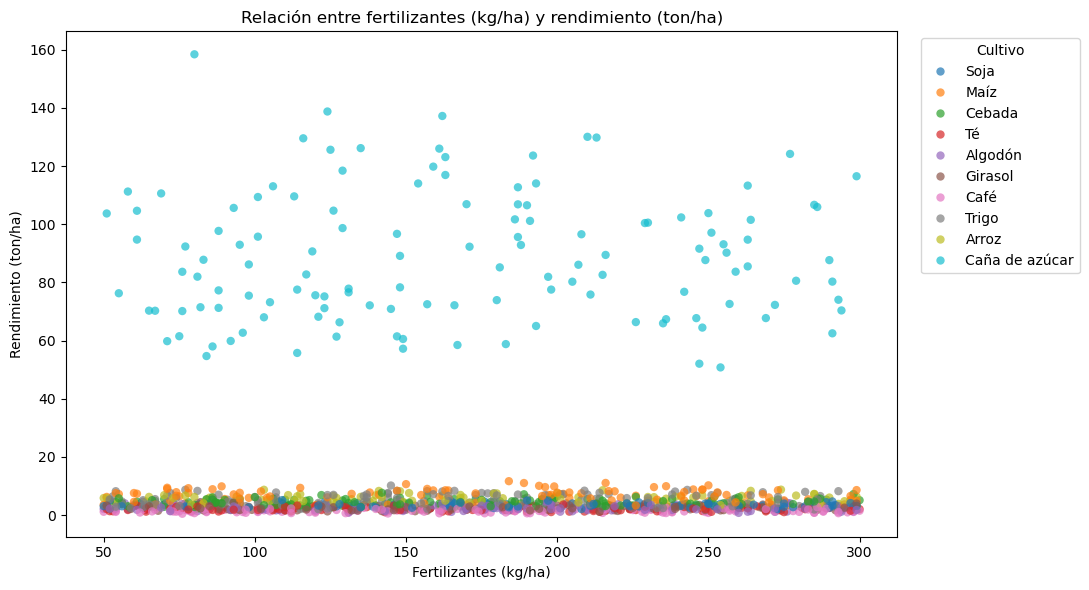


Correlación por cultivo:
  Algodón: -0.09  (n=120)
  Arroz: -0.02  (n=90)
  Café: 0.09  (n=130)
  Caña de azúcar: 0.02  (n=130)
  Cebada: 0.12  (n=140)
  Girasol: 0.05  (n=120)
  Maíz: -0.07  (n=110)
  Soja: 0.01  (n=110)
  Trigo: -0.00  (n=140)
  Té: -0.04  (n=110)


In [3]:
eda_df = datasets['produccion_agricola'][
    ['pais', 'region', 'cultivo', 'anio', 'fertilizantes_kg_ha', 'rendimiento_ton_ha']
].dropna()

print('Registros usados:', len(eda_df))
print('\nPrimeros registros:')
print(eda_df.head(5).to_string(index=False))

print('\nCorrelación global entre fertilizantes y rendimiento:')
print(eda_df[['fertilizantes_kg_ha', 'rendimiento_ton_ha']].corr())

plt.figure(figsize=(11, 6))
sns.scatterplot(
    data=eda_df,
    x='fertilizantes_kg_ha',
    y='rendimiento_ton_ha',
    hue='cultivo',
    alpha=0.7,
    edgecolor='none'
)
plt.title('Relación entre fertilizantes (kg/ha) y rendimiento (ton/ha)')
plt.xlabel('Fertilizantes (kg/ha)')
plt.ylabel('Rendimiento (ton/ha)')
plt.legend(title='Cultivo', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('\nCorrelación por cultivo:')
for cultivo, grupo in eda_df.groupby('cultivo'):
    corr = grupo['fertilizantes_kg_ha'].corr(grupo['rendimiento_ton_ha'])
    print(f'  {cultivo}: {corr:.2f}  (n={len(grupo)})')


In [4]:
datasets['condiciones_climaticas'].head()

,codigo_iso,pais,regiones_anio,regiones_dias_con_heladas,regiones_eventos_extremos,regiones_humedad_relativa_promedio,regiones_indice_aridez,regiones_meses_estres_hidrico,regiones_nombre,regiones_precipitacion_total,regiones_temperatura_maxima,regiones_temperatura_minima,regiones_temperatura_promedio
0,ARG,Argentina,2017,62,NaN,40,24.06,4,Cuyo,1074,22.5,"0,5",12.4
1,ARG,Argentina,2015,4,NaN,70,19.09,2,Cuyo,873,20.8,"0,9",12.7
2,ARG,Argentina,2019,111,NaN,64,16.19,1,Cuyo,880,29.9,"4,8",15.1
3,ARG,Argentina,2018,64,NaN,68,12.85,0,Cuyo,907,30.6,"6,6",19.6
4,ARG,Argentina,2016,93,NaN,83,29.64,0,Cuyo,1387,22.6,"7,2",13.0


In [5]:
datasets['imagenes_metadata'].head()

,imagen_id,pais,region,fecha,indice_ndvi_promedio,indice_ndvi_min,indice_ndvi_max,indice_evi,uso_suelo_predominante,humedad_suelo_estimada,cobertura_nubes,resolucion_metros,satelite,bandas_disponibles,calidad_imagen
0,SAT_FRA_202001_000,Francia,Región Principal,2020-01-15,0.391,0.259,0.432,0.432,bosque,0.378,0.074,30,MODIS,"RGB, NIR, SWIR",media
1,SAT_ARG_202001_001,Argentina,Noroeste,2020-01-31,0.488,0.390,0.601,0.555,mixto,0.480,0.055,30,Sentinel-2,"RGB, NIR, SWIR",baja
2,SAT_CHN_202003_002,China,Región Principal,2020-03-01,0.546,0.433,0.622,0.655,urbano,0.552,0.099,20,MODIS,"RGB, NIR, SWIR",baja
3,SAT_DEU_202003_003,Alemania,Región Principal,2020-03-12,0.601,0.446,0.655,0.744,urbano,0.644,0.209,60,Sentinel-2,"RGB, NIR, SWIR",media
4,SAT_FRA_202003_004,Francia,Región Principal,2020-03-22,0.639,0.518,0.753,0.792,mixto,0.441,0.249,10,Sentinel-2,"RGB, NIR, SWIR",baja
